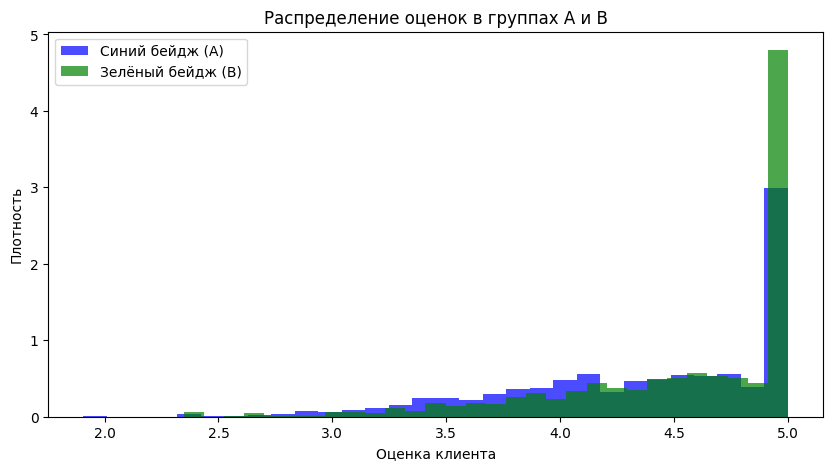

=== ОСНОВНЫЕ МЕТРИКИ ===
Группа A (синий): Среднее = 4.386, Стандартное отклонение = 0.600
Группа B (зелёный): Среднее = 4.547, Стандартное отклонение = 0.549
Разница в средних: 0.161


In [1]:
# @title
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Симулируем оценки клиентов (от 1 до 5)
np.random.seed(42)  # Для воспроизводимости
# Группа A (синий): среднее 4.5, небольшой разброс
group_a = np.random.normal(loc=4.5, scale=0.8, size=1000)
group_a = np.clip(group_a, 1, 5)  # Обрезаем до диапазона оценок

# Группа B (зелёный): среднее 4.7, такой же разброс
group_b = np.random.normal(loc=4.7, scale=0.8, size=1000)
group_b = np.clip(group_b, 1, 5)

# 2. Визуализируем
plt.figure(figsize=(10, 5))
plt.hist(group_a, bins=30, alpha=0.7, label='Синий бейдж (A)', color='blue', density=True)
plt.hist(group_b, bins=30, alpha=0.7, label='Зелёный бейдж (B)', color='green', density=True)
plt.xlabel('Оценка клиента')
plt.ylabel('Плотность')
plt.title('Распределение оценок в группах A и B')
plt.legend()
plt.show()

# 3. Рассчитываем основные метрики
print("=== ОСНОВНЫЕ МЕТРИКИ ===")
print(f"Группа A (синий): Среднее = {group_a.mean():.3f}, Стандартное отклонение = {group_a.std():.3f}")
print(f"Группа B (зелёный): Среднее = {group_b.mean():.3f}, Стандартное отклонение = {group_b.std():.3f}")
print(f"Разница в средних: {group_b.mean() - group_a.mean():.3f}")


=== СТАТИСТИЧЕСКАЯ ПРОВЕРКА ГИПОТЕЗЫ ===
t-статистика: 6.2635
P-value: 0.000000

Уровень значимости (alpha): 0.05
РЕЗУЛЬТАТ: p-value < alpha. ОТВЕРГАЕМ нулевую гипотезу.
Статистически значимые данные свидетельствуют, что ЗЕЛЁНЫЙ бейдж даёт БОЛЕЕ ВЫСОКИЕ оценки.


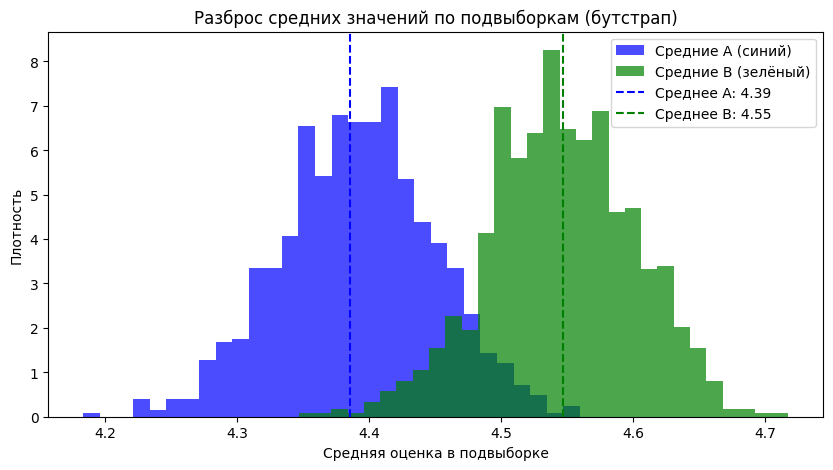

In [2]:
# @title
# 4. Проводим статистический тест (двухвыборочный t-тест)
# Проверяем, различаются ли СРЕДНИЕ двух групп
t_stat, p_value = stats.ttest_ind(group_b, group_a, alternative='greater')  # Проверяем, что group_b > group_a

print("\n=== СТАТИСТИЧЕСКАЯ ПРОВЕРКА ГИПОТЕЗЫ ===")
print(f"t-статистика: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# 5. Интерпретируем результат
alpha = 0.05  # Уровень значимости (стандартный порог 5%)
print(f"\nУровень значимости (alpha): {alpha}")
if p_value < alpha:
    print("РЕЗУЛЬТАТ: p-value < alpha. ОТВЕРГАЕМ нулевую гипотезу.")
    print("Статистически значимые данные свидетельствуют, что ЗЕЛЁНЫЙ бейдж даёт БОЛЕЕ ВЫСОКИЕ оценки.")
else:
    print("РЕЗУЛЬТАТ: p-value >= alpha. НЕ ОТВЕРГАЕМ нулевую гипотезу.")
    print("НЕТ статистически значимых доказательств, что зелёный бейдж лучше синего.")

# 6. Дополнительная визуализация для понимания "разброса средних"
# Покажем, как могут варьироваться средние в случайных подвыборках
np.random.seed(42)
sample_means_a = [np.random.choice(group_a, 100, replace=True).mean() for _ in range(1000)]
sample_means_b = [np.random.choice(group_b, 100, replace=True).mean() for _ in range(1000)]

plt.figure(figsize=(10, 5))
plt.hist(sample_means_a, bins=30, alpha=0.7, label='Средние A (синий)', color='blue', density=True)
plt.hist(sample_means_b, bins=30, alpha=0.7, label='Средние B (зелёный)', color='green', density=True)
plt.axvline(x=group_a.mean(), color='blue', linestyle='--', label=f'Среднее A: {group_a.mean():.2f}')
plt.axvline(x=group_b.mean(), color='green', linestyle='--', label=f'Среднее B: {group_b.mean():.2f}')
plt.xlabel('Средняя оценка в подвыборке')
plt.ylabel('Плотность')
plt.title('Разброс средних значений по подвыборкам (бутстрап)')
plt.legend()
plt.show()

In [3]:
# @title
# 7. РАСЧЁТ БИЗНЕС-ЭФФЕКТА (практическая значимость)
print("\n=== АНАЛИЗ БИЗНЕС-ЦЕЛЕСООБРАЗНОСТИ ===")

# Предположения:
num_couriers = 5000          # Всего курьеров в компании
cost_per_uniform = 2500      # Стоимость нового комплекта формы (бейдж+рубашка)
conversion_rate_old = 0.12   # Конверсия в повторный заказ при синем бейдже (12%)
conversion_rate_new = 0.124  # Конверсия при зелёном (предположим рост на 0.4% из-за +0.2 балла)
avg_order_value = 1500       # Средний чек, руб
orders_per_month = 50_000    # Всего заказов в месяц

# Затраты на внедрение
total_cost = num_couriers * cost_per_uniform
print(f"1. СТОИМОСТЬ ВНЕДРЕНИЯ (переодевание всех курьеров): {total_cost:,} руб")

# Выгода за год (упрощённо)
additional_orders = orders_per_month * 12 * (conversion_rate_new - conversion_rate_old)
additional_profit = additional_orders * avg_order_value
print(f"2. ДОПОЛНИТЕЛЬНАЯ ВЫРУЧКА В ГОД: {additional_profit:,.0f} руб")

# Окупаемость
roi_months = total_cost / (additional_profit / 12) if additional_profit > 0 else float('inf')
print(f"3. ОКУПАЕМОСТЬ: {roi_months:.1f} месяцев")

# Рекомендация
if roi_months <= 12:
    print("\n✅ РЕКОМЕНДАЦИЯ: Внедрять. Инвестиции окупятся в течение года.")
else:
    print("\n⚠️ РЕКОМЕНДАЦИЯ: НЕ внедрять в текущем виде. Искать более эффективные улучшения.")


=== АНАЛИЗ БИЗНЕС-ЦЕЛЕСООБРАЗНОСТИ ===
1. СТОИМОСТЬ ВНЕДРЕНИЯ (переодевание всех курьеров): 12,500,000 руб
2. ДОПОЛНИТЕЛЬНАЯ ВЫРУЧКА В ГОД: 3,600,000 руб
3. ОКУПАЕМОСТЬ: 41.7 месяцев

⚠️ РЕКОМЕНДАЦИЯ: НЕ внедрять в текущем виде. Искать более эффективные улучшения.
